In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv("AI Job Market Dataset.csv")

In [3]:
X = df[['experience_level']]
y = df['salary']

In [6]:
X = pd.get_dummies(X)

In [8]:
print(X.isnull().sum())

experience_level_Entry     0
experience_level_Mid       0
experience_level_Senior    0
dtype: int64


In [11]:
X = X.fillna(0)
print(X)

       experience_level_Entry  experience_level_Mid  experience_level_Senior
0                       False                 False                     True
1                       False                  True                    False
2                       False                  True                    False
3                       False                  True                    False
4                       False                  True                    False
...                       ...                   ...                      ...
10340                    True                 False                    False
10341                    True                 False                    False
10342                    True                 False                    False
10343                   False                  True                    False
10344                   False                  True                    False

[10345 rows x 3 columns]


In [12]:
print(X.dtypes)

experience_level_Entry     bool
experience_level_Mid       bool
experience_level_Senior    bool
dtype: object


In [13]:
from sklearn.preprocessing import OneHotEncoder
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error,r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test,y_pred))

MAE: 20389.85653200112
R2 Score: 0.4040923434017897


In [17]:
import pandas as pd
results = pd.DataFrame({
    'Actual': y_pred,
    'Predicted': y_pred})
print(results.head())

          Actual      Predicted
0   89053.746121   89053.746121
1   89053.746121   89053.746121
2  113293.703113  113293.703113
3  138130.708972  138130.708972
4  138130.708972  138130.708972


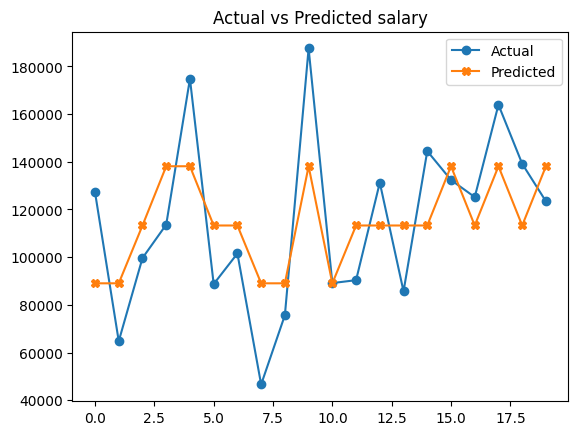

In [18]:
import matplotlib.pyplot as plt
plt.plot(y_test.values[:20], marker='o', label='Actual')
plt.plot(y_pred[:20], marker='X',label='Predicted')

plt.title("Actual vs Predicted salary")
plt.legend()
plt.show()

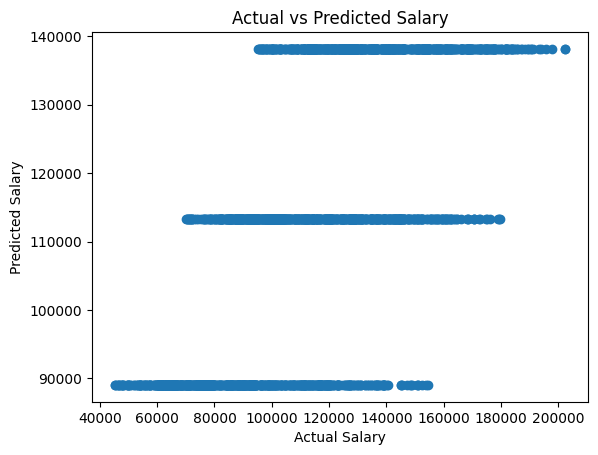

In [22]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [23]:
import joblib
joblib.dump(model, "salary_model.pkl")

['salary_model.pkl']